# Exploratory Data Analysis (EDA)

**Input:**
* `rccarbonation.xlsx` (Raw dataset)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
try:
    df = pd.read_excel('rccarbonation.xlsx')
    
    # Apply the same preprocessing/mapping as the Training Notebook
    # This ensures we analyze the data exactly as the model sees it
    mapping_dict = {
        r'\bPIA\b': '0', r'\bUEA\b': '1', r'\bPEA\b': '2',
        r'\bCPII Z\b': '0', r'\bCPV - ARI\b': '1', r'\bCPIV\b': '2',
        r'\bCPII F\b': '3', r'\bCPIII\b': '4', r'\bCPII E\b': '5',
    }
    df.replace(mapping_dict, regex=True, inplace=True)
    
    # Ensure numeric types for correlation calculation
    for col in ['Exposure conditions', 'Type of cement']:
        df[col] = pd.to_numeric(df[col])

    print("Data loaded successfully. Shape:", df.shape)
    display(df.head())

except FileNotFoundError:
    print("ERROR: File 'rccarbonation.xlsx' not found.")

Data loaded successfully. Shape: (20000, 7)


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178


### 1. Descriptive Statistics

Here we examine the central tendency (mean, median) and dispersion (standard deviation) of the data.

In [3]:
# Display summary statistics transposed for better readability
stats = df.describe().T
display(stats)

,count,mean,std,min,25%,50%,75%,max
CCO₂ (%),20000.0,0.164796,0.078089,0.03,0.10000,0.16000,0.23000,0.3000
fc (MPa),20000.0,34.900490,8.662669,20.00,27.40000,34.80000,42.40000,50.0000
RH (%),20000.0,59.939055,17.305382,30.00,44.90000,60.10000,74.90000,90.0000
Type of cement,20000.0,2.506900,1.705725,0.00,1.00000,3.00000,4.00000,5.0000
Exposure conditions,20000.0,0.992100,0.816377,0.00,0.00000,1.00000,2.00000,2.0000
t (years),20000.0,49.933550,29.320048,0.00,24.00000,50.00000,75.00000,100.0000
Possan,20000.0,16.591604,12.842477,0.00,7.79345,13.21595,21.53135,119.7121


### 2. Correlation Analysis

The Heatmap below visualizes the Pearson correlation coefficients between variables.
* **Positive values (blue):** Indicate a direct relationship (e.g., as Time increases, Carbonation Depth increases).
* **Negative values (red):** Indicate an inverse relationship (e.g., higher Compressive Strength reduces Carbonation).

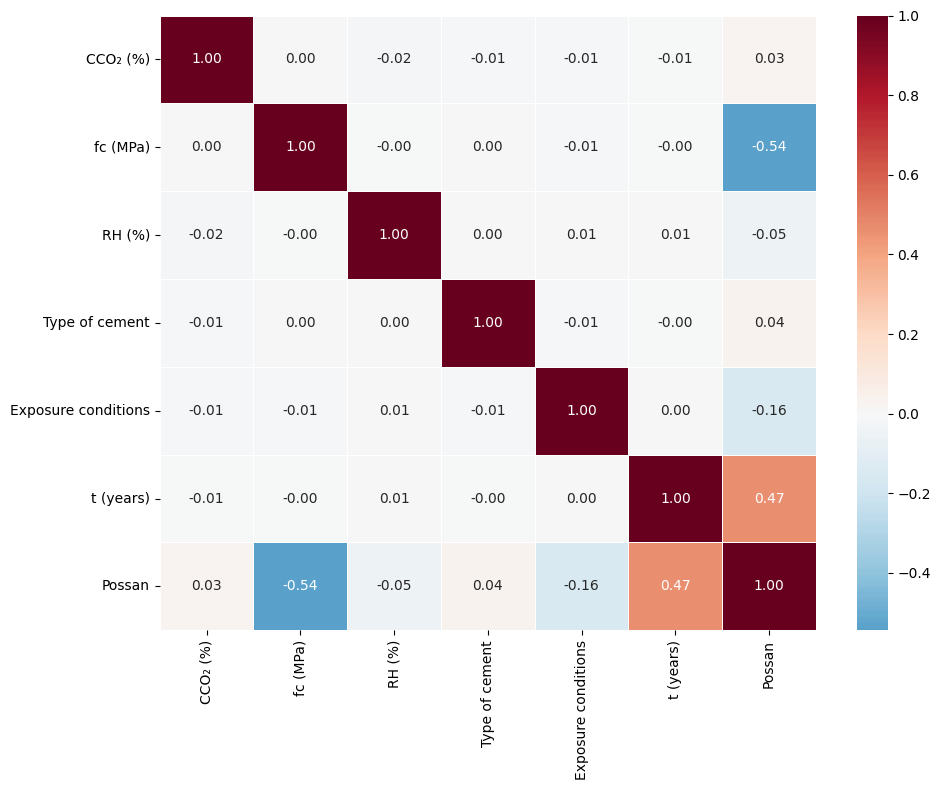

In [4]:
plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = df.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r',     # Red-Blue colormap
            center=0, 
            linewidths=0.5, 
            linecolor='white')


plt.tight_layout()
plt.show()

### 3. Feature vs. Target Analysis

Scatter plots allow us to visualize the specific relationship between each input feature and the target variable (**Carbonation Depth**).
We focus on key factors: Time ($t$), $CO_2$ Concentration, Relative Humidity ($RH$), and Compressive Strength ($f_{ck}$).

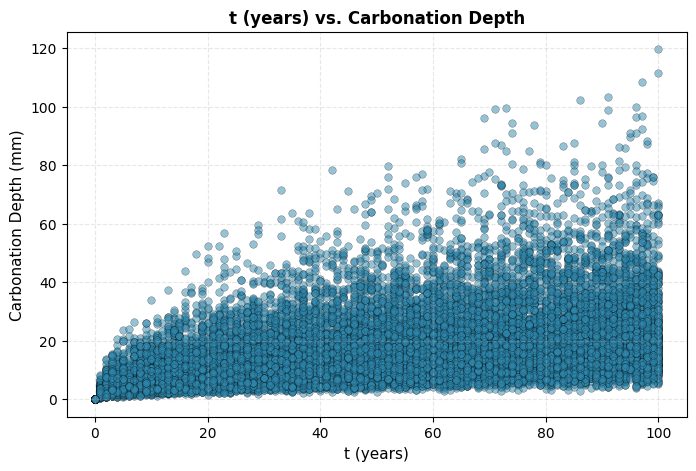

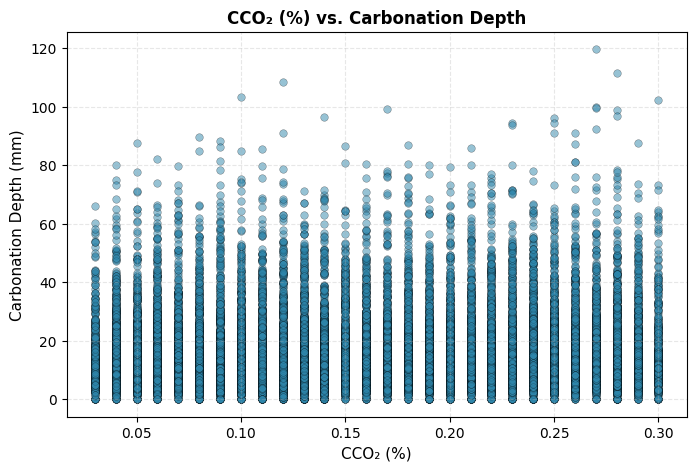

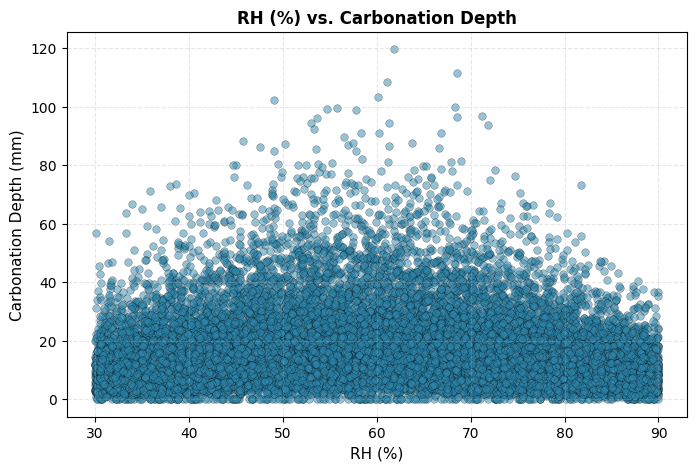

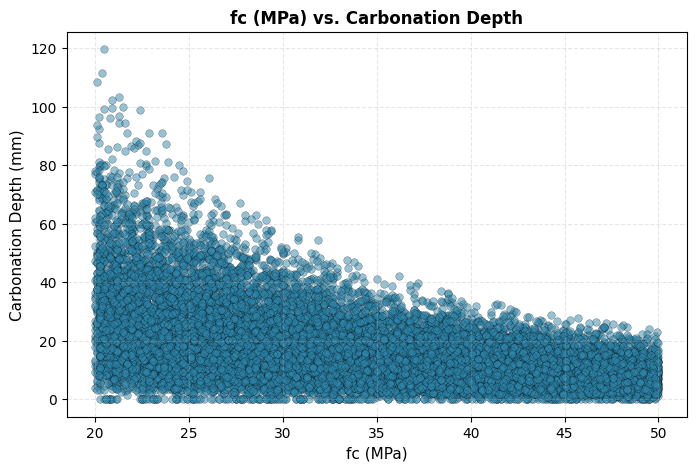

In [5]:
def plot_scatter(df, x_col, y_col='Possan'):
    """
    Plots a scatter graph between a feature and the target variable.
    """
    plt.figure(figsize=(8, 5))
    
    plt.scatter(df[x_col], df[y_col], 
                alpha=0.5, 
                c='#2E86AB',       # Petrol Blue
                edgecolor='k', 
                linewidth=0.3,
                s=30)
    
    plt.title(f'{x_col} vs. Carbonation Depth', fontsize=12, fontweight='bold')
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel('Carbonation Depth (mm)', fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    
    plt.show()

# List of features to analyze
features = ['t (years)', 'CCO₂ (%)', 'RH (%)', 'fc (MPa)']

for feature in features:
    plot_scatter(df, feature)